# PyG sanity check: GCNConv & GATConv on your **raw Reactome DAG** (not the padded BINN graph)

This notebook is a **plumbing + graph-integrity** check:

- Load **your generated raw graph** from `outputs/graph/` (DAG: genes → pathways → parents)
- Run basic diagnostics (DAG check, connected components, isolated nodes, root reachability)
- Visualize a **small subgraph** so you can see it is not disconnected
- Train **vanilla PyTorch Geometric** models:
  - `GCNConv`
  - `GATConv`

Goal: confirm that **PyG GCN/GAT can train on your graph + data**, before doing method comparisons or hyperparameter sweeps.

Why not `outputs/graph_layered_binn/`?

That folder contains the **padded layered** graph created to mimic feed-forward BINN constraints (fixed depth + dummy/copy nodes). In the paper, this is the “extra steps” transformation (artificial stratification). The raw DAG is the natural input for GNNs.  


In [4]:
import sys
from pathlib import Path
import os

PROJECT_ROOT = Path("/home/maani/niloo/binn_gnn_repo_ready/binn_gnn_repo_ready")

sys.path.append(str(PROJECT_ROOT / "src"))
os.environ["BINN_GNN_BASE"] = str(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)
BASE_DIR = Path(os.environ.get("BINN_GNN_BASE", ".")).resolve()


Project root: /home/maani/niloo/binn_gnn_repo_ready/binn_gnn_repo_ready


In [5]:
# === 1) Install / import dependencies ===
# (Safe to rerun; pip will skip if already installed)
!pip -q install torch-geometric networkx scikit-learn matplotlib tqdm

import numpy as np
import pandas as pd
import torch

import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [6]:
# === 2) Paths to your saved artifacts (from Notebook 01) ===
OUT_DIR = BASE_DIR / "outputs"

RAW_GRAPH_DIR = OUT_DIR / "graph"               # <-- RAW graph (for GNN)
LAYERED_GRAPH_DIR = OUT_DIR / "graph_layered_binn"  # padded BINN graph (NOT used here)

EXPR_PARQUET = OUT_DIR / "expr_reactome_tcga_tumor_normal.parquet"
Y_CSV        = OUT_DIR / "y_tcga_tumor_normal.csv"

required = [
    RAW_GRAPH_DIR / "node_table.csv",
    RAW_GRAPH_DIR / "edge_index.pt",
    EXPR_PARQUET,
    Y_CSV,
]

missing = [str(p) for p in required if not Path(p).exists()]
if missing:
    raise FileNotFoundError("Missing required artifacts:\n" + "\n".join(missing))

print("Artifacts OK")
print("RAW_GRAPH_DIR:", RAW_GRAPH_DIR)

Artifacts OK
RAW_GRAPH_DIR: /home/maani/niloo/binn_gnn_repo_ready/binn_gnn_repo_ready/outputs/graph


In [7]:
# === 3) Load expression + labels ===
expr = pd.read_parquet(EXPR_PARQUET)  # genes x samples
y_df = pd.read_csv(Y_CSV, index_col=0)

samples = y_df.index.astype(str).tolist()
y = y_df.iloc[:, 0].to_numpy(dtype=np.int64)

# align expression columns
expr = expr.loc[:, samples]

print("expr:", expr.shape, "(genes x samples)")
print("y:", y.shape, "pos rate:", y.mean().round(3))

expr: (11403, 9912) (genes x samples)
y: (9912,) pos rate: 0.927


In [8]:
# === 4) Load raw graph (DAG) ===
node_table = pd.read_csv(RAW_GRAPH_DIR / "node_table.csv")
edge_index = torch.load(RAW_GRAPH_DIR / "edge_index.pt").long()

num_nodes = node_table.shape[0]
num_edges = edge_index.shape[1]

print("num_nodes:", num_nodes)
print("num_edges:", num_edges)
print(node_table.head())

# build a NetworkX directed graph for diagnostics
G_dir = nx.DiGraph()
G_dir.add_nodes_from(range(num_nodes))
G_dir.add_edges_from(edge_index.t().tolist())

print("Is DAG?", nx.is_directed_acyclic_graph(G_dir))

# Node-type counts
type_counts = node_table["node_type"].value_counts()
display(type_counts)

# Roots in this orientation = nodes with out_degree==0 (no parent)
out_deg = dict(G_dir.out_degree())
root_nodes = [n for n, d in out_deg.items() if d == 0]
print("root_nodes:", len(root_nodes))

# Undirected connectivity
G_und = G_dir.to_undirected()
comps = list(nx.connected_components(G_und))
comp_sizes = sorted([len(c) for c in comps], reverse=True)
print("Connected components (undirected):", len(comps))
print("Largest component size:", comp_sizes[0], f"({comp_sizes[0]/num_nodes:.1%} of nodes)")

# Isolated nodes
isolated = list(nx.isolates(G_und))
print("Isolated nodes:", len(isolated))

# Reachability to ANY root (sampled for speed)
# A node can reach a root iff it is in the descendant set of roots in the reversed graph.
G_rev = G_dir.reverse(copy=False)
reachable = set()
for r in root_nodes[: min(10, len(root_nodes))]:
    reachable |= nx.descendants(G_rev, r)
    reachable.add(r)
print("Nodes that can reach one of first roots (upper bound):", len(reachable), f"({len(reachable)/num_nodes:.1%})")

num_nodes: 14201
num_edges: 140581
   node_id        node_name node_type
0        0  ENSG00000000419      gene
1        1  ENSG00000000460      gene
2        2  ENSG00000000938      gene
3        3  ENSG00000000971      gene
4        4  ENSG00000001036      gene


/tmp/ipykernel_2156134/865453740.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  edge_index = torch.load(RAW_GRAPH_DIR / "edge_index.pt").long()


Is DAG? True


node_type
gene       11403
pathway     2798
Name: count, dtype: int64

root_nodes: 29
Connected components (undirected): 1
Largest component size: 14201 (100.0% of nodes)
Isolated nodes: 0
Nodes that can reach one of first roots (upper bound): 9060 (63.8%)


Subgraph nodes: 200 edges: 199


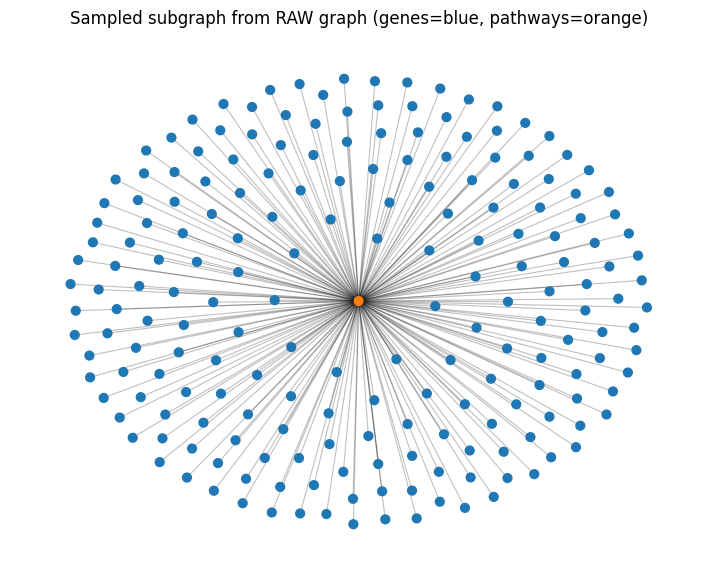

In [9]:
# === 5) Visualize a small subgraph (readable) ===
# We pick one root (if available), then take a BFS neighbourhood in the undirected graph.

import random
random.seed(0)

if len(root_nodes) > 0:
    start = root_nodes[0]
else:
    start = random.randrange(num_nodes)

# BFS to collect up to N nodes
N_VIS = 200
visited = {start}
queue = [start]
while queue and len(visited) < N_VIS:
    v = queue.pop(0)
    for u in G_und.neighbors(v):
        if u not in visited:
            visited.add(u)
            queue.append(u)
        if len(visited) >= N_VIS:
            break

sub_nodes = sorted(list(visited))
H = G_und.subgraph(sub_nodes).copy()
print("Subgraph nodes:", H.number_of_nodes(), "edges:", H.number_of_edges())

# Layout + draw
pos = nx.spring_layout(H, seed=0, k=0.5)
node_types = node_table.set_index("node_id")["node_type"].to_dict()
colors = ["tab:blue" if node_types[n]=="gene" else "tab:orange" for n in H.nodes()]

plt.figure(figsize=(9,7))
nx.draw_networkx_edges(H, pos, alpha=0.25, width=0.8)
nx.draw_networkx_nodes(H, pos, node_size=40, node_color=colors)
plt.title("Sampled subgraph from RAW graph (genes=blue, pathways=orange)")
plt.axis("off")
plt.show()

In [10]:
# === 6) Build a PyG dataset: each patient is one graph with the SAME topology ===

# Map expression genes -> node ids in raw graph
gene_rows = node_table.query("node_type=='gene'")[["node_name","node_id"]].copy()
gene_to_id = dict(zip(gene_rows["node_name"].astype(str), gene_rows["node_id"].astype(int)))

expr_genes = expr.index.astype(str).tolist()
genes_in_graph = [g for g in expr_genes if g in gene_to_id]
missing_genes = [g for g in expr_genes if g not in gene_to_id]

print("Genes in expr:", len(expr_genes))
print("Genes also in raw graph:", len(genes_in_graph))
print("Missing genes (dropped):", len(missing_genes))

# Filter expression to genes present in graph
expr_f = expr.loc[genes_in_graph].copy()

# Fixed list of gene node ids in the SAME order as expr_f index
gene_node_ids = torch.tensor([gene_to_id[g] for g in expr_f.index.astype(str)], dtype=torch.long)

# Split indices ONCE (shared)
idx = np.arange(expr_f.shape[1])
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)

# Standardize gene features (train-only fit)
X_all = expr_f.T.to_numpy(dtype=np.float32)   # samples x genes
scaler = StandardScaler()
X_all[train_idx] = scaler.fit_transform(X_all[train_idx])
X_all[val_idx]   = scaler.transform(X_all[val_idx])

# Choose a small subset for a quick sanity run (increase later)
MAX_SAMPLES = 400
keep = np.concatenate([train_idx[:MAX_SAMPLES//2], val_idx[:MAX_SAMPLES//2]])
keep = np.unique(keep)
train_idx = np.array([i for i in train_idx if i in keep])
val_idx   = np.array([i for i in val_idx if i in keep])

print("Using samples:", len(keep), "| train:", len(train_idx), "val:", len(val_idx))

# Edge handling:
# GCNConv is typically used on undirected graphs. We symmetrize by default.
MAKE_UNDIRECTED = True
edge_index_use = edge_index
if MAKE_UNDIRECTED:
    edge_rev = edge_index.flip(0)
    edge_index_use = torch.cat([edge_index, edge_rev], dim=1)
    edge_index_use = torch.unique(edge_index_use, dim=1)
print("edge_index_use:", edge_index_use.shape)

def make_data(sample_i: int) -> Data:
    x = torch.zeros((num_nodes, 1), dtype=torch.float32)
    x[gene_node_ids, 0] = torch.from_numpy(X_all[sample_i])
    data = Data(x=x, edge_index=edge_index_use, y=torch.tensor([y[sample_i]], dtype=torch.float32))
    return data

train_list = [make_data(i) for i in train_idx]
val_list   = [make_data(i) for i in val_idx]

train_loader = DataLoader(train_list, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_list, batch_size=32, shuffle=False)

print("PyG dataset built.")

Genes in expr: 11403
Genes also in raw graph: 11403
Missing genes (dropped): 0
Using samples: 400 | train: 200 val: 200
edge_index_use: torch.Size([2, 281162])
PyG dataset built.


In [11]:
# === 7) Define vanilla PyG models ===
import torch.nn as nn
import torch.nn.functional as F

class VanillaGCN(nn.Module):
    def __init__(self, in_dim=1, hidden_dim=32, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin = nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)  # graph embedding
        return self.lin(x).view(-1)

class VanillaGAT(nn.Module):
    def __init__(self, in_dim=1, hidden_dim=16, heads=4, dropout=0.3):
        super().__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_dim*heads, hidden_dim, heads=1, concat=True, dropout=dropout)
        self.lin = nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        x = F.elu(x)
        x = global_mean_pool(x, batch)
        return self.lin(x).view(-1)

def eval_auc(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch)
            prob = torch.sigmoid(logits).cpu().numpy()
            ys.append(batch.y.view(-1).cpu().numpy())
            ps.append(prob)
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    return float(roc_auc_score(y_true, y_pred))

def train_model(model, epochs=20, lr=1e-3, weight_decay=1e-5):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()

    hist = {"train_loss": [], "val_auc": []}
    for ep in range(1, epochs+1):
        model.train()
        losses = []
        for batch in train_loader:
            batch = batch.to(device)
            opt.zero_grad()
            logits = model(batch)
            loss = loss_fn(logits, batch.y.view(-1))
            loss.backward()
            opt.step()
            losses.append(loss.item())
        val_auc = eval_auc(model, val_loader)
        hist["train_loss"].append(float(np.mean(losses)))
        hist["val_auc"].append(val_auc)
        print(f"epoch {ep:03d} | loss {hist['train_loss'][-1]:.4f} | val_auc {val_auc:.4f}")
    return model, hist

epoch 001 | loss 0.6250 | val_auc 0.6912
epoch 002 | loss 0.6032 | val_auc 0.5767
epoch 003 | loss 0.5739 | val_auc 0.5782
epoch 004 | loss 0.5406 | val_auc 0.5830
epoch 005 | loss 0.5017 | val_auc 0.5690
epoch 006 | loss 0.4493 | val_auc 0.5594
epoch 007 | loss 0.3924 | val_auc 0.5474
epoch 008 | loss 0.3547 | val_auc 0.5329
epoch 009 | loss 0.3169 | val_auc 0.5310
epoch 010 | loss 0.2999 | val_auc 0.5262
epoch 011 | loss 0.2923 | val_auc 0.5402
epoch 012 | loss 0.3126 | val_auc 0.5541
epoch 013 | loss 0.3011 | val_auc 0.5589
epoch 014 | loss 0.2898 | val_auc 0.5618
epoch 015 | loss 0.3014 | val_auc 0.5657
epoch 016 | loss 0.3029 | val_auc 0.5873
epoch 017 | loss 0.2888 | val_auc 0.5998
epoch 018 | loss 0.2882 | val_auc 0.6056
epoch 019 | loss 0.2993 | val_auc 0.6118
epoch 020 | loss 0.2886 | val_auc 0.6190


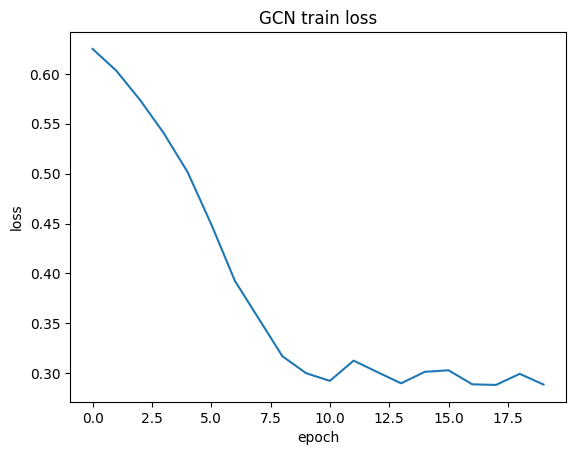

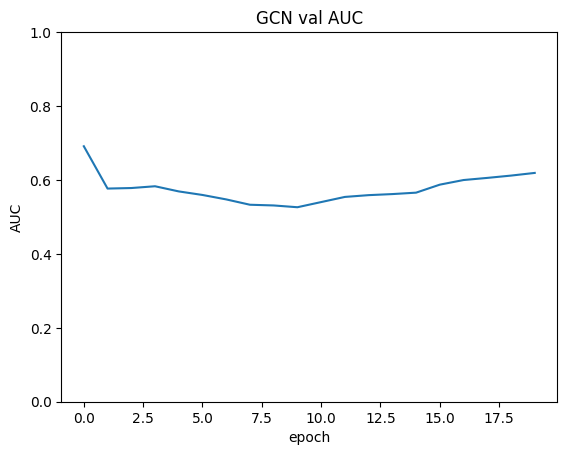

In [12]:
# === 8) Train vanilla GCNConv ===
gcn = VanillaGCN(in_dim=1, hidden_dim=32, dropout=0.3)
gcn, hist_gcn = train_model(gcn, epochs=20, lr=1e-3, weight_decay=1e-5)

plt.figure()
plt.plot(hist_gcn["train_loss"])
plt.title("GCN train loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

plt.figure()
plt.plot(hist_gcn["val_auc"])
plt.title("GCN val AUC")
plt.xlabel("epoch")
plt.ylabel("AUC")
plt.ylim(0.0, 1.0)
plt.show()

epoch 001 | loss 0.7582 | val_auc 0.2597
epoch 002 | loss 0.6791 | val_auc 0.3016
epoch 003 | loss 0.5764 | val_auc 0.3362
epoch 004 | loss 0.4519 | val_auc 0.3550
epoch 005 | loss 0.3501 | val_auc 0.3747
epoch 006 | loss 0.3021 | val_auc 0.3819
epoch 007 | loss 0.2969 | val_auc 0.3939
epoch 008 | loss 0.2804 | val_auc 0.4098
epoch 009 | loss 0.2913 | val_auc 0.4247
epoch 010 | loss 0.2790 | val_auc 0.4459
epoch 011 | loss 0.2864 | val_auc 0.4666
epoch 012 | loss 0.2886 | val_auc 0.4892
epoch 013 | loss 0.2868 | val_auc 0.5224
epoch 014 | loss 0.2869 | val_auc 0.5517
epoch 015 | loss 0.2755 | val_auc 0.5657
epoch 016 | loss 0.2728 | val_auc 0.5839
epoch 017 | loss 0.2963 | val_auc 0.5859
epoch 018 | loss 0.2839 | val_auc 0.6219
epoch 019 | loss 0.2833 | val_auc 0.6469
epoch 020 | loss 0.2955 | val_auc 0.6604


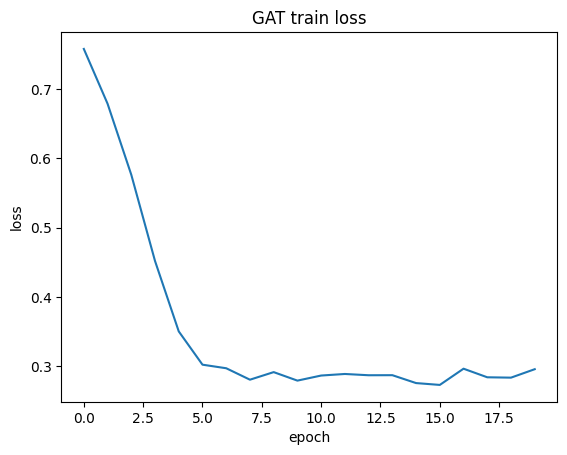

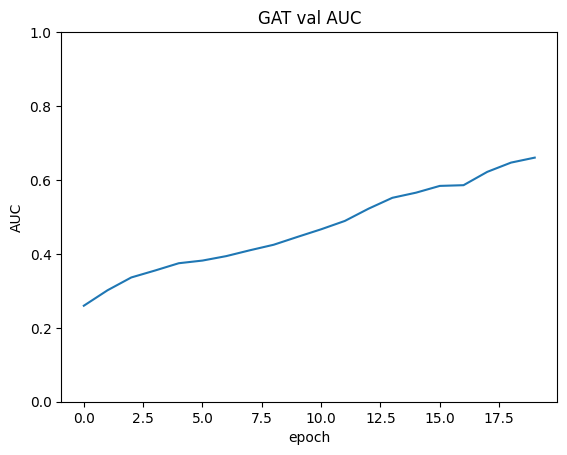

In [13]:
# === 9) Train vanilla GATConv ===
gat = VanillaGAT(in_dim=1, hidden_dim=16, heads=4, dropout=0.3)
gat, hist_gat = train_model(gat, epochs=20, lr=1e-3, weight_decay=1e-5)

plt.figure()
plt.plot(hist_gat["train_loss"])
plt.title("GAT train loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

plt.figure()
plt.plot(hist_gat["val_auc"])
plt.title("GAT val AUC")
plt.xlabel("epoch")
plt.ylabel("AUC")
plt.ylim(0.0, 1.0)
plt.show()

## Interpreting this sanity check

If you see:
- loss decreasing and
- AUC consistently > ~0.5

then PyG GCN/GAT **can train** on your graph+data.  

If AUC stays at chance:
- try setting `MAKE_UNDIRECTED=False` vs `True`
- try fewer layers (1 conv)
- try larger hidden_dim (64) and smaller dropout
- confirm expression standardization is enabled (it is by default here)
